In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt


In [3]:
# Load data
X_train = pd.read_pickle("../data/processed/X_train.pkl")

# Load trained model
model = joblib.load("../models/best_model.pkl")

# Extract feature importance (coefficients)
importance = model.coef_[0]
features = X_train.columns

fi_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

fi_df["abs_importance"] = fi_df["importance"].abs()
fi_df = fi_df.sort_values("abs_importance", ascending=False)

fi_df.head(10)


,feature,importance,abs_importance
0,FamilySize,-0.916431,0.916431
6,IsFemale,0.712962,0.712962
23,Title_Mrs,0.636959,0.636959
7,HasCabin,0.513754,0.513754
18,Title_Master,0.501423,0.501423
25,Title_Rev,-0.315984,0.315984
22,Title_Mr,-0.303862,0.303862
3,FareFilled,0.255808,0.255808
19,Title_Miss,0.230329,0.230329
9,EmbarkedFilled_S,-0.183673,0.183673


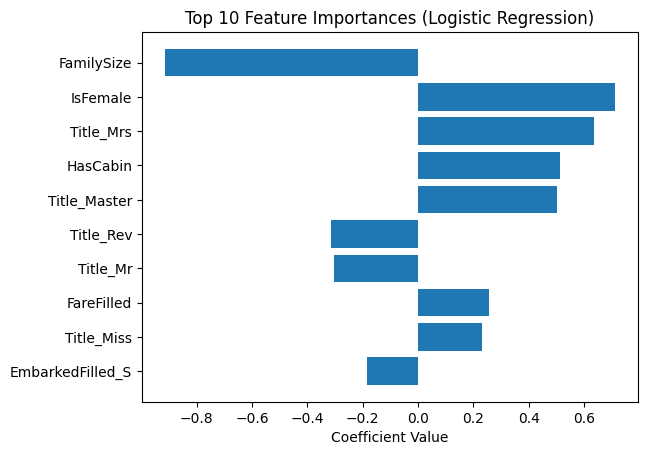

In [6]:
plt.figure()
plt.barh(fi_df["feature"][:10], fi_df["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()
